In [2]:
zhs = open('data/names1/names1.txt','r').read().splitlines()
pinyins = open('data/names1/names1_pinyin_components.txt','r').read().splitlines()

for zh,p in zip(zhs[:10],pinyins[:10]):      
    print(f'{zh:5}\t{p}')
len(zhs),len(pinyins)

倪|子宁 	n i | z i n ing
宋|云深 	s ong | y un sh en
尤|听澜 	y ou | t ing l an
唐|承安 	t ang | ch eng _ an
龙|长宁 	l ong | zh ang n ing
田|清玄 	t ian | q ing x uan
柯|川  	k e | ch uan
郑|灵微 	zh eng | l ing w ei
任|瑶音 	r en | y ao y in
汪|音  	w ang | y in


(12000, 12000)

In [3]:
print(pinyins[0].split())

# tokenized_pinyins = []
# for p in pinyins:
#    tokenized_pinyins.append(p.split())

tokenized_pinyins = [p.split() for p in pinyins]
len(tokenized_pinyins),tokenized_pinyins[:5]

['n', 'i', '|', 'z', 'i', 'n', 'ing']


(12000,
 [['n', 'i', '|', 'z', 'i', 'n', 'ing'],
  ['s', 'ong', '|', 'y', 'un', 'sh', 'en'],
  ['y', 'ou', '|', 't', 'ing', 'l', 'an'],
  ['t', 'ang', '|', 'ch', 'eng', '_', 'an'],
  ['l', 'ong', '|', 'zh', 'ang', 'n', 'ing']])

In [39]:
# 去除重复元素
tokens = sorted(set(t for ts in tokenized_pinyins for t in ts))
stoi = {s:i+1 for i,s in enumerate(tokens)}

stoi['.'] = 0 # 开始和结束符
itos = {i+1:s for i,s in enumerate(tokens)}
itos[0] = '.'


len(tokens),stoi['.'],stoi['an'],itos[0],itos[57],len(stoi),len(itos)

(57, 0, 4, '.', '|', 58, 58)

In [5]:
import torch
token_count = len(stoi)
N = torch.zeros(token_count,token_count,dtype=torch.int32)
N.shape

torch.Size([58, 58])

In [6]:
for ts in tokenized_pinyins:
    seq = ['.'] + ts + ['.']
    for t1,t2 in zip(seq,seq[1:]):
        ix1 = stoi[t1]
        ix2 = stoi[t2]        
        N[ix1,ix2] += 1
N.shape,N.sum()       

(torch.Size([58, 58]), tensor(92916))

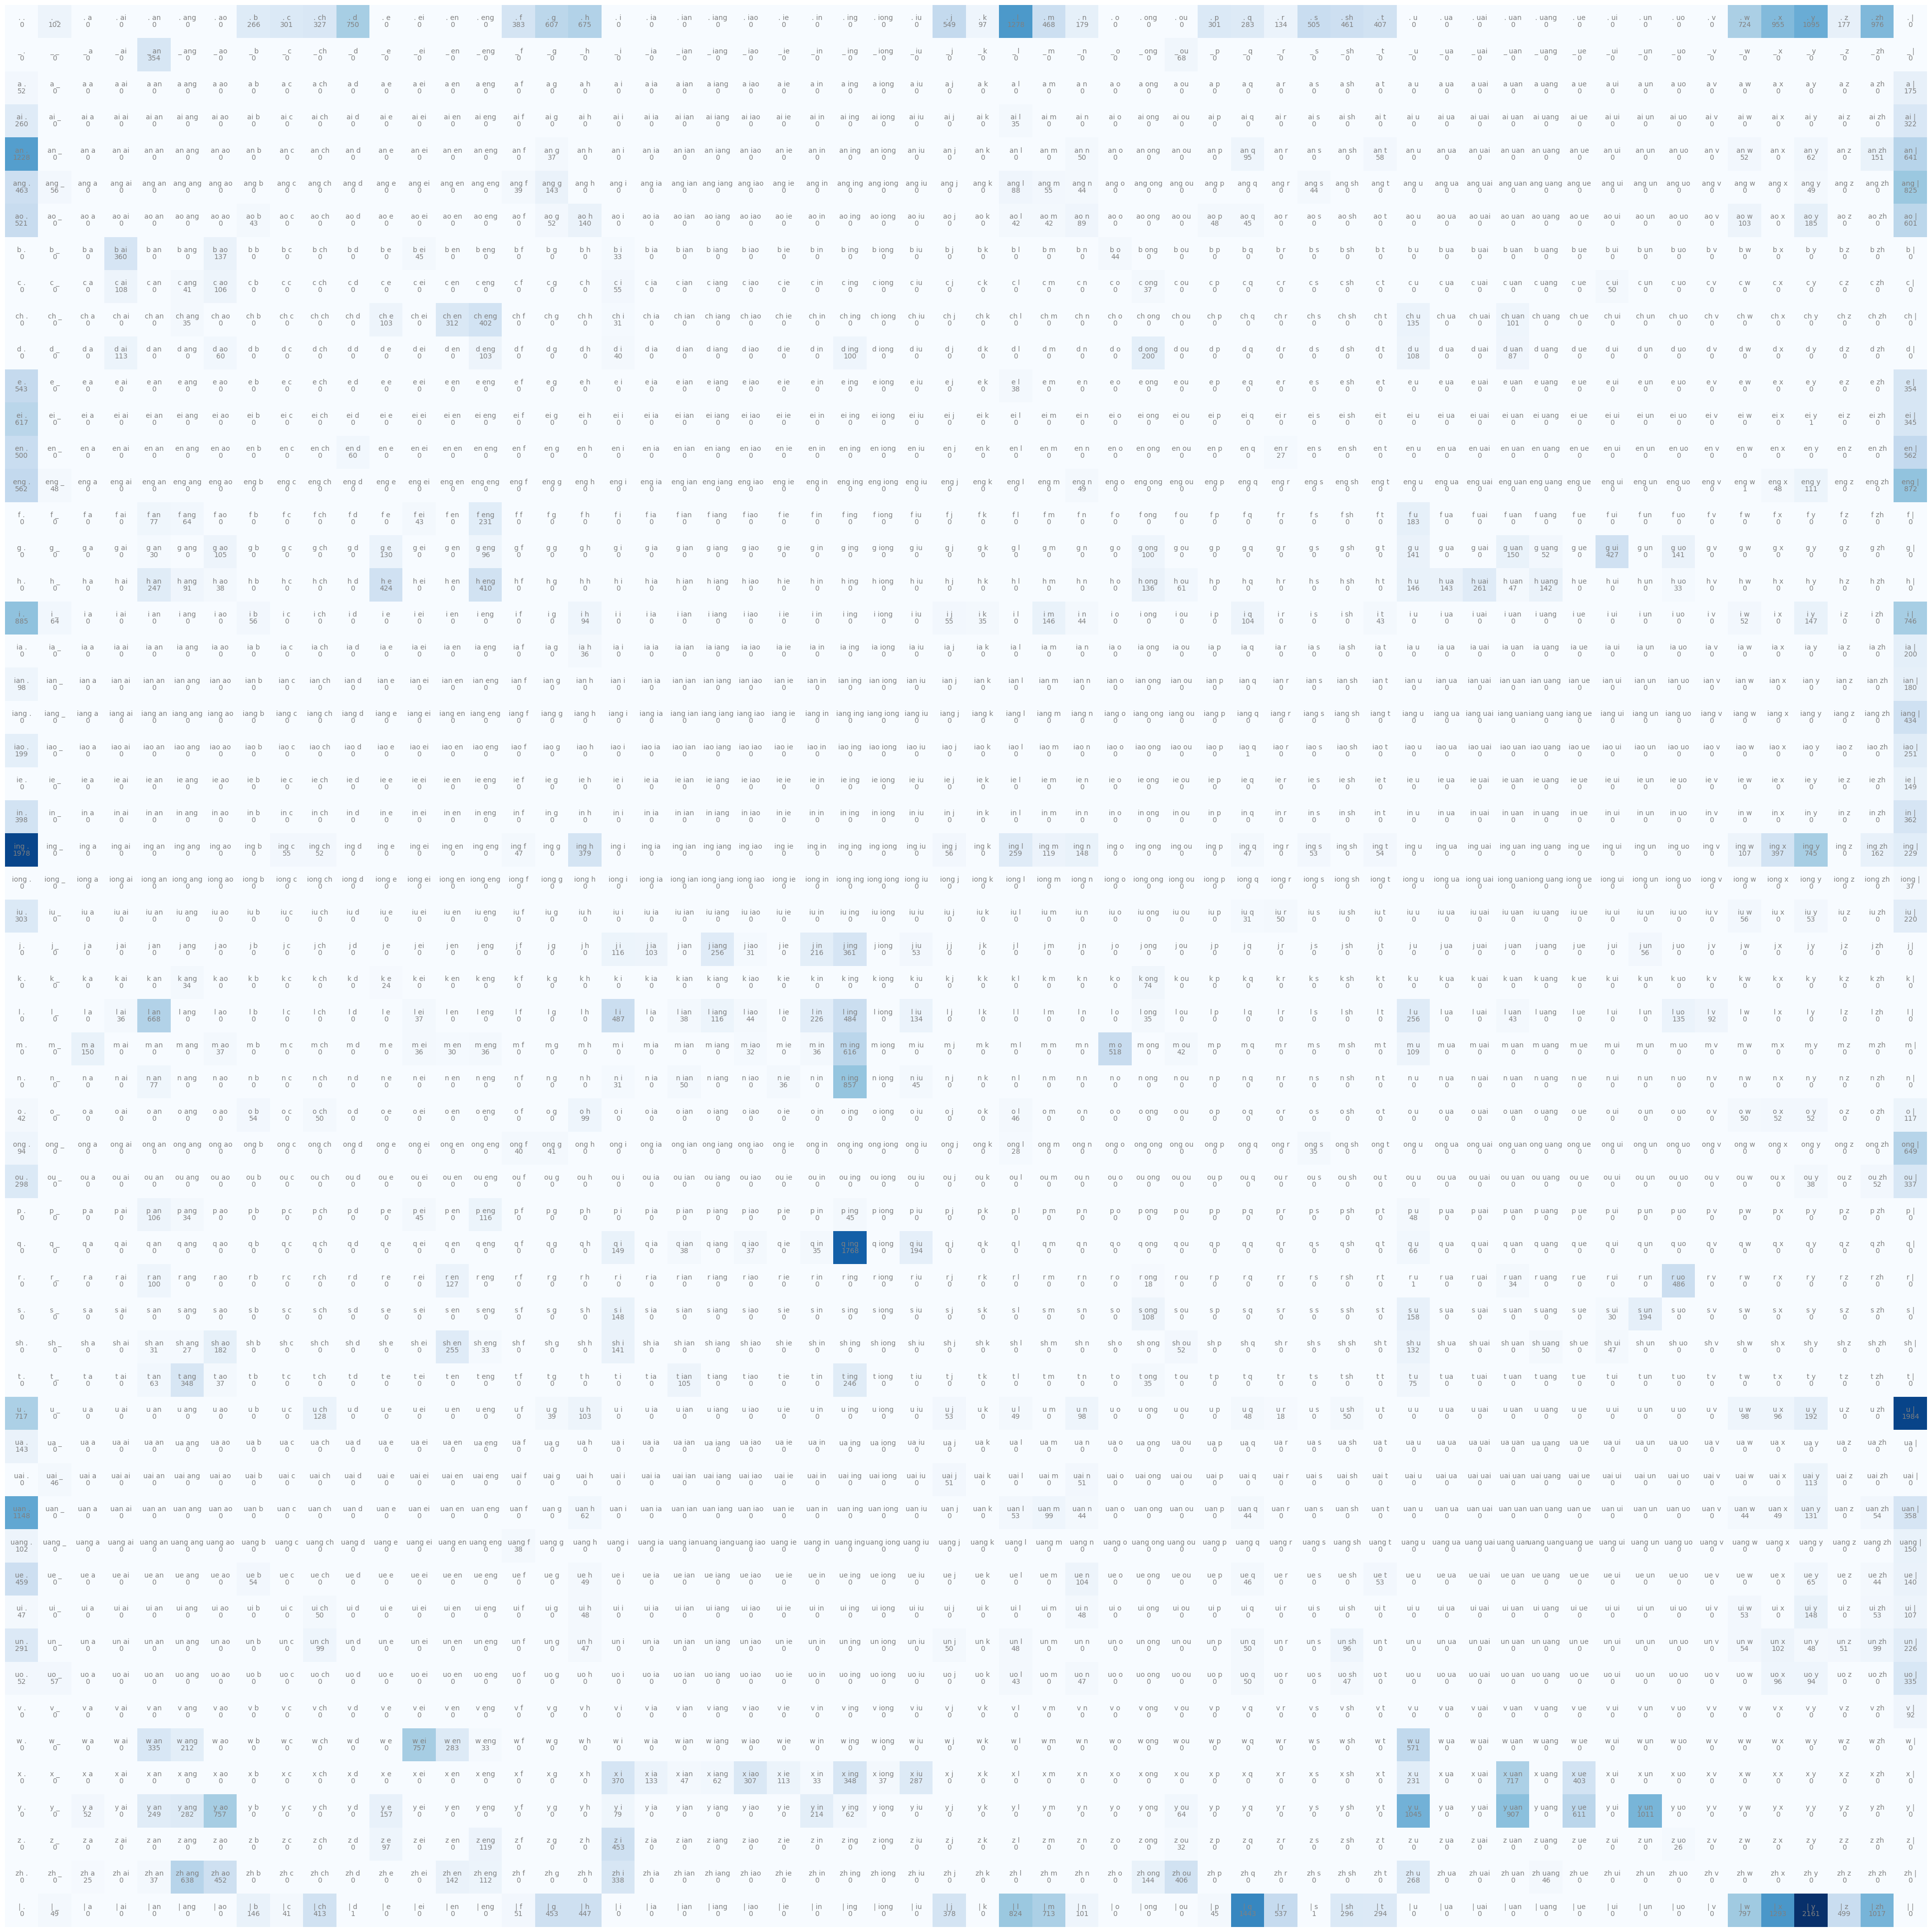

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(50,50))
plt.imshow(N,cmap='Blues')

for i in range(token_count):
    for j in range(token_count):
        token_str = itos[i]+' '+itos[j]
        plt.text(j,i,token_str,ha='center',va='bottom',color='gray')
        plt.text(j,i,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off');


In [8]:
P=N.float()
P/=P.sum(1,keepdim=True)
P.shape,P[0].sum()

(torch.Size([58, 58]), tensor(1.0000))

In [9]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3,generator=g)
p/=p.sum()
ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
ix,itos[ix]

(0, '.')

In [15]:
g = torch.Generator().manual_seed(2147483647)

samples=[]
for i in range(100):
    has_first_name = False
    out = []
    ix = 0  #'.'起始
    while True:
        ix = torch.multinomial(P[ix],num_samples=1,replacement=True,generator=g).item()
        char = itos[ix]
        # 确保每次采样一个姓氏一个名
        if char=='.':
            if has_first_name:
                break
            else:
                continue
        if char=='|':
            if not has_first_name:
                has_first_name = True
            else:
                break        
        out.append(char)
        
        # #小于5个字
        # if len(out)>=4*2 :
        #     break
    samples.append(out)
i=0        
for o in samples:
    print(f'{i:03d}:{o}')
    i+=1 

000:['n', 'ing', 'l', 'iang', '|', 'x', 'u']
001:['x', 'ing', 'g', 'ui', 'zh', 'ang', 'l', 'in', '|', 'm', 'a']
002:['s', 'un', 'ch', 'en', 'r', 'uo', '|', 'y', 'un']
003:['zh', 'a', '|', 'ch', 'eng']
004:['l', 'an', '|', 'ch', 'uan']
005:['n', 'ian', '|', 'q', 'ing']
006:['t', 'ang', 'y', 'in', '|', 'y', 'ao', 'q', 'ing', 'zh', 'i']
007:['j', 'iao', '|', 'y', 'i', 'y', 'ue']
008:['zh', 'ao', 'w', 'ang', '|', 'zh', 'uang']
009:['g', 'uan', 'q', 'ing', 'l', 'i', 'ch', 'e', '|', 'h', 'e']
010:['zh', 'i', 'b', 'ai', '|', 't', 'ian']
011:['y', 'u', 'h', 'e', 'm', 'ing', 'h', 'ong', '|', 'p', 'an']
012:['_', 'ou', '|', 'q', 'ing']
013:['q', 'ing', 'g', 'ui', 'y', 'uan', '|', 'j', 'ing', 'zh', 'ao', 'w', 'u']
014:['l', 'in', '|', 'zh', 'i']
015:['k', 'ong', '|', 'j', 'iang']
016:['s', 'un', '|', 'y', 'in']
017:['m', 'o', 'h', 'eng', 'y', 'u', '|', 't', 'ing']
018:['s', 'ong', '|', 'r', 'en']
019:['zh', 'i', '|', 'sh', 'en']
020:['zh', 'ao', 'y', 'an', 'w', 'ei', 'c', 'i', '|', 'zh', 'ao']
02

In [16]:
# 解码成中文
INITIALS = {
    '_', 'b','p','m','f','d','t','n','l','g','k','h',
    'j','q','x','r','z','c','s','y','w','zh','ch','sh'
}

FINALS = {
    'a','o','e','i','u','v',
    'ai','ei','ui','ao','ou','iu','ie','ue','er',
    'an','en','in','un','vn',
    'ang','eng','ing','ong',
    'ia','iao','ian','iang','iong',
    'ua','uo','uai','uan','uang'
}
def is_valid(tokens):
    
    # 只能有一个姓氏
    if tokens.count('|') != 1:
        return False

    # 必须有一个姓氏和一个名
    sep = tokens.index('|')
    if sep == 0 or sep == len(tokens) - 1:
        return False

    # 确保声母和韵母配对
    parts = tokens[:sep] + tokens[sep + 1:]
    if len(parts) % 2 != 0:
        return False

    # # 小于5个汉字
    # if len(parts)/2 > 5:
    #     return False

    # 必须在声韵表中
    for i in range(0, len(parts), 2):
        if parts[i] not in INITIALS:
            return False
        if parts[i + 1] not in FINALS:
            return False

    return True

[is_valid(o) for o in samples[:10]]

[True, True, True, True, True, True, True, True, True, True]

In [ ]:
def load_component_char_mapping(path):
    mapping = {}

    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            key, chars_text = line.split('\t', 1)
            mapping[key] = chars_text.split()

    return mapping

mapping = load_component_char_mapping('data/names1/pinyin_components_to_hanzi_chars1.txt')
len(mapping),mapping.get('h an')

(188, ['含', '韩', '涵', '寒'])

In [13]:

import random

def tokens_to_syllable_keys(tokens):
    sep = tokens.index('|')
    parts = tokens[:sep] + tokens[sep + 1:]

    keys = []
    for i in range(0, len(parts), 2):
        keys.append(parts[i] + ' ' + parts[i + 1])

    return keys

def sample_hanzi_name(tokens, mapping, rng=random):
    keys = tokens_to_syllable_keys(tokens)
    if keys is None:
        return None

    chars = []
    for k in keys:
        choices = mapping.get(k)
        if not choices:
            return None
        chars.append(rng.choice(choices))# 随机选一个字

    return ''.join(chars)


In [38]:
def tokens_side_to_syllable_keys(parts):
    keys = []
    for i in range(0, len(parts), 2):
        keys.append(parts[i] + ' ' + parts[i + 1])
    return keys

def keys_to_pretty_pinyin(keys):
    return ' '.join(k.replace(' ', '') for k in keys)

def sample_hanzi_side(keys, mapping, rng=random):
    chars = []
    for k in keys:
        choices = mapping.get(k)
        if not choices:
            return None
        chars.append(rng.choice(choices))
    return ''.join(chars)

def sample_hanzi_name_with_sep(tokens, mapping, rng=random):
    sep = tokens.index('|')

    left_keys = tokens_side_to_syllable_keys(tokens[:sep])
    right_keys = tokens_side_to_syllable_keys(tokens[sep + 1:])

    left_hanzi = sample_hanzi_side(left_keys, mapping, rng)
    right_hanzi = sample_hanzi_side(right_keys, mapping, rng)

    if left_hanzi is None or right_hanzi is None:
        return None

    pretty = keys_to_pretty_pinyin(left_keys) + ' | ' + keys_to_pretty_pinyin(right_keys)
    hanzi = left_hanzi + ' | ' + right_hanzi

    return pretty, hanzi

for i, s in enumerate(samples):
    result = sample_hanzi_name_with_sep(s, mapping)
    if result is None:
        print(f'{i:03d} [<INVALID>] --> [<UNK>]')
        continue

    pretty, hanzi = result
    print(f'{i:03d} [{pretty:32}] --> [{hanzi}]')


000 [ning liang | xu                 ] --> [宁梁 | 许]
001 [xing gui zhang lin | ma         ] --> [星桂长临 | 马]
002 [sun chen ruo | yun              ] --> [孙陈若 | 云]
003 [zha | cheng                     ] --> [查 | 程]
004 [lan | chuan                     ] --> [岚 | 川]
005 [nian | qing                     ] --> [念 | 晴]
006 [tang yin | yao qing zhi         ] --> [汤殷 | 姚清执]
007 [jiao | yi yue                   ] --> [焦 | 衣月]
008 [zhao wang | zhuang              ] --> [昭汪 | 庄]
009 [guan qing li che | he           ] --> [关清里澈 | 和]
010 [zhi bai | tian                  ] --> [执白 | 田]
011 [yu he ming hong | pan           ] --> [玉和冥洪 | 潘]
012 [_ou | qing                      ] --> [欧 | 晴]
013 [qing gui yuan | jing zhao wu    ] --> [清桂辕 | 景赵无]
014 [lin | zhi                       ] --> [临 | 执]
015 [kong | jiang                    ] --> [空 | 蒋]
016 [sun | yin                       ] --> [孙 | 尹]
017 [mo heng yu | ting               ] --> [墨衡羽 | 听]
018 [song | ren                      ] --> [宋 | 任]
019 [zh